# 00 — Project Overview
## HPB Fintech Hackathon 2026

This notebook is the **single entry point** for the project. It summarizes the pipeline, links each step to its notebook, and shows the headline results. No heavy computation lives here — it is a map, not a workflow step.

If you only have 5 minutes, read this notebook. If you want to dig in, follow the links to notebooks 01–05.

## Problem

A Croatian bank wants to:

1. **Predict** which customers are at risk of churning (losing all core products: accounts, loans, deposits) in the next quarter.
2. **Decide** which retention action to take per customer — nothing, push, email, or call — so that retained revenue exceeds intervention cost.

We split the problem into two models:

- **Model 1** — supervised churn probability (LightGBM).
- **Model 2** — contextual bandit that maps the customer context to the cost-optimal action.

## Pipeline at a glance

```
  raw CSVs           features         churn model              bandit
  ─────────          ────────         ───────────              ──────
  data/raw/  ──▶  01_eda  ──▶  02_data_preparation  ──▶  03_lightgbm_baseline
                                                   └─▶  04_lightgbm_enhanced  ──▶  05_contextual_bandit
                                                                                        ▲
                                                                    scripts/generate_bandit_dataset.py
```

| Step | Notebook | What happens |
|------|----------|--------------|
| 1 | [01_eda.ipynb](01_eda.ipynb) | Inspect the 5 raw tables, define the churn label, build the initial 10-feature set. |
| 2 | [02_data_preparation.ipynb](02_data_preparation.ipynb) | Missing-value handling, distribution checks, low-correlation verification. Produces `churn_features_clean.csv`. |
| 3 | [03_lightgbm_baseline.ipynb](03_lightgbm_baseline.ipynb) | LightGBM on 10 features with SMOTE, Optuna, threshold tuning, SHAP. Baseline score to beat. |
| 4 | [04_lightgbm_enhanced.ipynb](04_lightgbm_enhanced.ipynb) | Adds 10 more features (demographics + richer behavior). This is the **strongest churn model** and the one the bandit consumes. |
| 5 | [05_contextual_bandit.ipynb](05_contextual_bandit.ipynb) | Per-action Ridge reward model, ε-greedy exploration, 24-month cumulative refit. Learns which action to send to whom. |

## Headline results

**Churn model (test set):**

| Model | F1 | ROC AUC | PR AUC |
|-------|-----|---------|--------|
| Baseline (10 features) — nb 03 | 0.386 | — | — |
| Enhanced (20 features) — nb 04 | **0.583** | 0.942 | 0.367 |

F1 improves **+51 %** from baseline → enhanced.

**Contextual bandit (holdout last 6 months):** the learned policy beats every static baseline (*always no action*, *always push*, *always email*, *always call*), and calls correctly concentrate on high-value + high-risk customers.

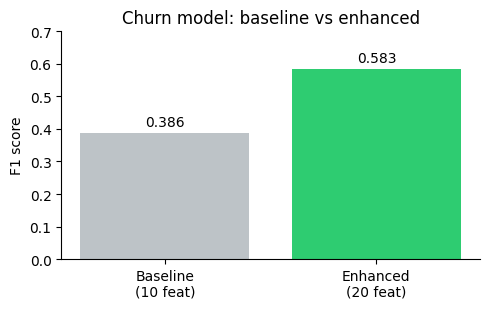

In [1]:
# Quick visual: F1 baseline vs enhanced churn model.
import matplotlib.pyplot as plt

models = ['Baseline\n(10 feat)', 'Enhanced\n(20 feat)']
f1     = [0.386, 0.583]

fig, ax = plt.subplots(figsize=(5, 3.2))
bars = ax.bar(models, f1, color=['#bdc3c7', '#2ecc71'])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, 0.7)
ax.set_ylabel('F1 score')
ax.set_title('Churn model: baseline vs enhanced')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Where to change things

| You want to… | Go to |
|--------------|-------|
| Add an EDA chart | [01_eda.ipynb](01_eda.ipynb) |
| Add / transform a feature | [01_eda.ipynb](01_eda.ipynb) (raw → feature) and [02_data_preparation.ipynb](02_data_preparation.ipynb) (cleaning) |
| Try a different churn classifier | copy [04_lightgbm_enhanced.ipynb](04_lightgbm_enhanced.ipynb) and swap the model — it already loads the cleaned enhanced dataset |
| Re-tune hyperparameters | the Optuna block in notebooks 03 / 04 |
| Change retention actions, their costs, or the reward definition | [scripts/generate_bandit_dataset.py](../scripts/generate_bandit_dataset.py), then re-run notebook 05 |
| Change the bandit policy (exploration, HTE features) | [05_contextual_bandit.ipynb](05_contextual_bandit.ipynb) |

## Further reading

- `docs/documentation.pdf` — full churn-model write-up
- `docs/contextual_bandit.pdf` — bandit derivation and design choices
- `docs/pitch.pdf` — presentation deck
- `docs/data_model.jpg` — raw-table ER diagram